<a href="https://colab.research.google.com/github/PrashVenga/AMLDM-CW-PART-1-FINAL-SUB-1-/blob/IBM-CW1-Part-1-Final-Sub-Codes/Copy_of_IBM_CW2_(Part1)_Final_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IBM HR Employee Attrition Analysis

**Important Notice**

Before running this notebook, please ensure the dataset file  
`IBM HR Employee Attrition.csv` is uploaded to your Google Drive under:

`MyDrive/IBM HR Employee Attrition.csv`

Google Drive must be mounted in Colab before loading the dataset.  
If the file path differs, please update the path in the dataset loading cell accordingly.

# **Library Imports**

Required libraries for data processing, visualisation, and machine learning are imported for the analysis and modelling tasks.

In [43]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

## **Dataset Loading**

Google Drive is mounted to access the IBM HR Employee Attrition dataset.  
### The dataset is loaded from the specified path and the first five rows and shape are displayed to verify successful import.

In [44]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# Loading the dataset
# at the specified path: '/content/drive/MyDrive/IBM HR Employee Attrition.csv'.

# Please ensure Google Drive is mounted and the path to the CSV file is accurate.
df = pd.read_csv('/content/drive/MyDrive/IBM HR Employee Attrition.csv')

# Displaying the first 5 rows and basic info
print("Dataset Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# **Duplicate Check**

A duplicate record check is performed to ensure data integrity before preprocessing and modelling.

In [45]:
# Checking duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# **Data Structure Overview**

The dataset structure is examined to verify data types and confirm the absence of missing values.

In [46]:
# Checking the data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# **Descriptive Statistics**

Summary statistics are generated for numerical and categorical variables to understand data distribution and feature characteristics.

In [47]:
# Statistical summary for numerical features
numerical_summary = df.describe()

# Statistical summary for categorical features
categorical_summary = df.describe(include=['O'])

print("Numerical Summary:")
display(numerical_summary)
print("\nCategorical Summary:")
display(categorical_summary)

Numerical Summary:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Categorical Summary:


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


# **Data Quality Assessment**

Missing values and unique value counts are examined to identify potential data issues such as null entries or redundant features.

In [48]:
# Check for missing values
missing_values = df.isnull().sum()

# Check for unique values in each column to find redundant data
unique_counts = df.nunique()

quality_report = pd.DataFrame({
    'Missing Values': missing_values,
    'Unique Values': unique_counts
})

print(quality_report)

                          Missing Values  Unique Values
Age                                    0             43
Attrition                              0              2
BusinessTravel                         0              3
DailyRate                              0            886
Department                             0              3
DistanceFromHome                       0             29
Education                              0              5
EducationField                         0              6
EmployeeCount                          0              1
EmployeeNumber                         0           1470
EnvironmentSatisfaction                0              4
Gender                                 0              2
HourlyRate                             0             71
JobInvolvement                         0              4
JobLevel                               0              5
JobRole                                0              9
JobSatisfaction                        0        

# **Target Variable Distribution**

The distribution of the target variable (Attrition) is visualised to assess class balance and identify potential imbalance before model development.

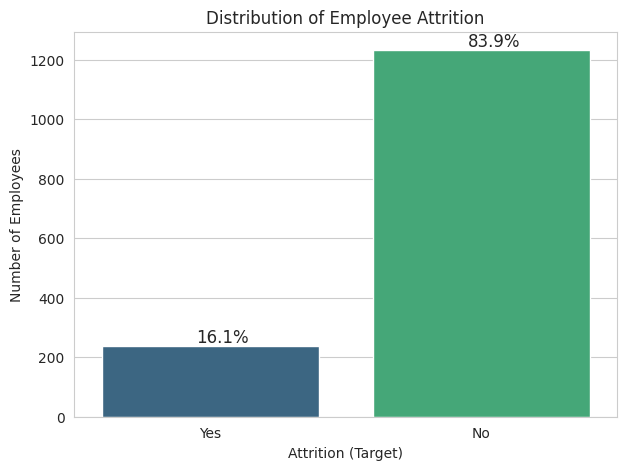

In [49]:
# Creating the visual style
sns.set_style("whitegrid")

# Plotting the distribution of Attrition
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Attrition', data=df, hue='Attrition', palette='viridis', legend=False)
plt.title('Distribution of Employee Attrition')
plt.xlabel('Attrition (Target)')
plt.ylabel('Number of Employees')

# Adding percentage labels
total = len(df['Attrition'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), size = 12, va='bottom')

plt.show()

# **Boxplot Analysis of Key Numerical Features**

Boxplots are generated to compare selected numerical features across attrition groups, allowing visual assessment of differences in age, income, experience, and commuting distance.

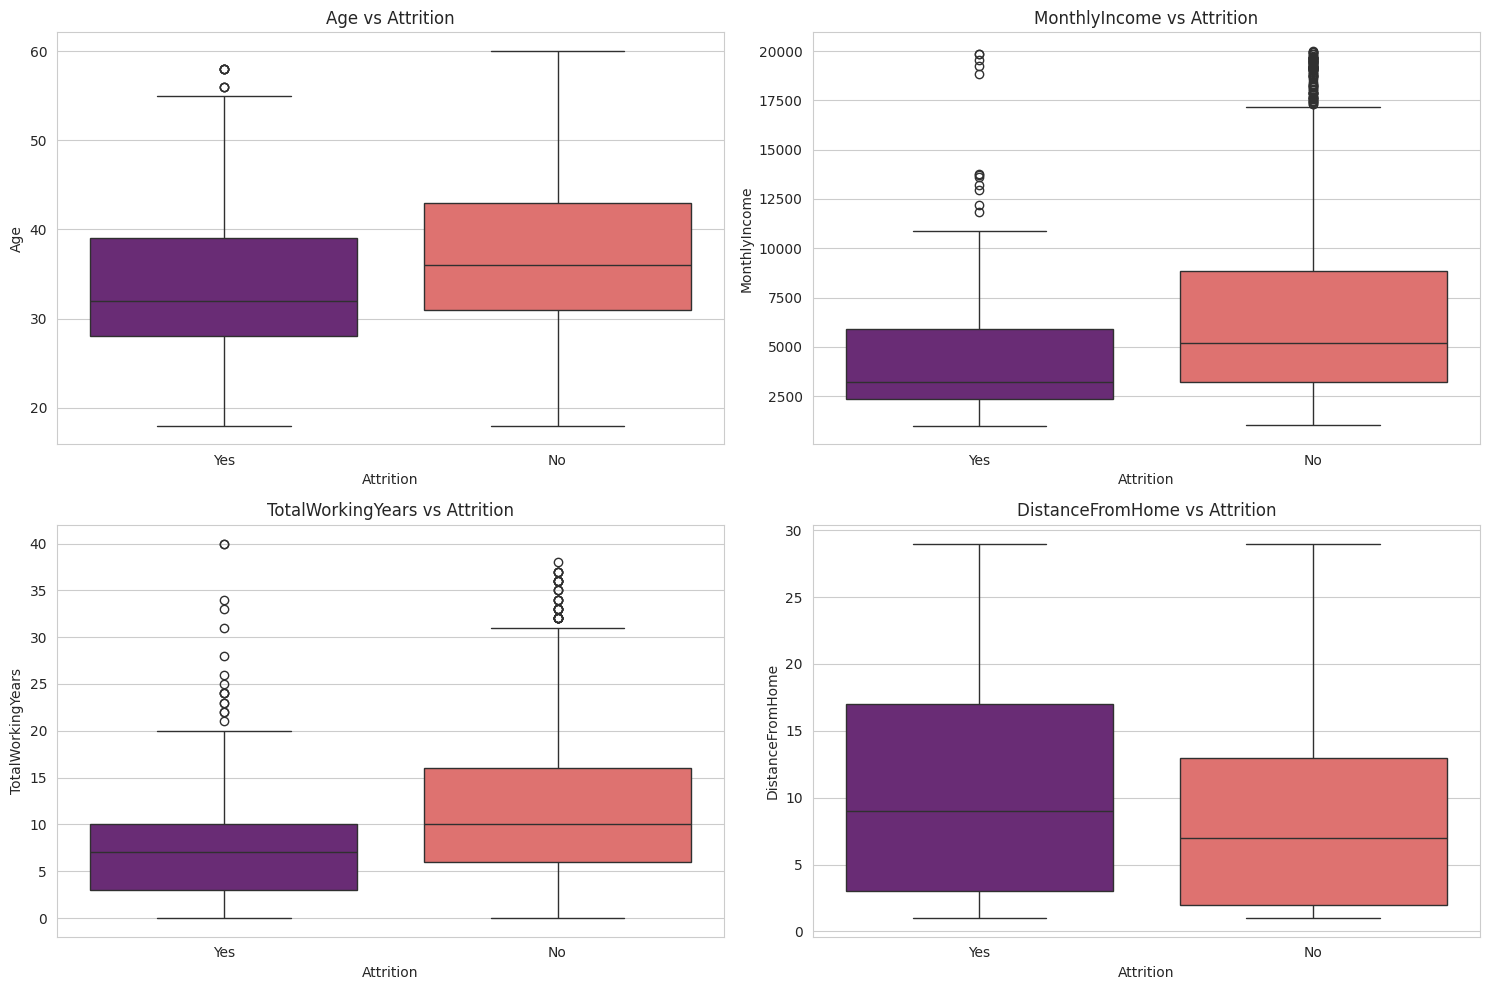

In [50]:
# List of key numerical features
features = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'DistanceFromHome']

plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(
    x='Attrition',
    y=col,
    hue='Attrition',
    data=df,
    palette='magma',
    legend=False
)
    plt.title(f'{col} vs Attrition')

plt.tight_layout()
plt.show()

# **Attrition by Overtime and Job Role**

Attrition patterns are analysed across overtime status and job roles to identify workload and

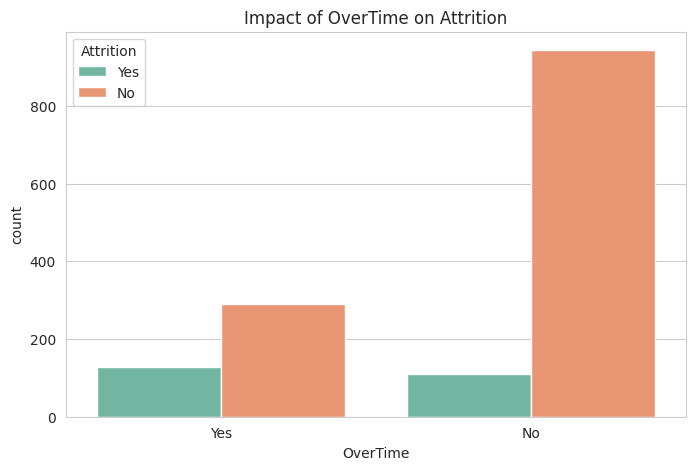

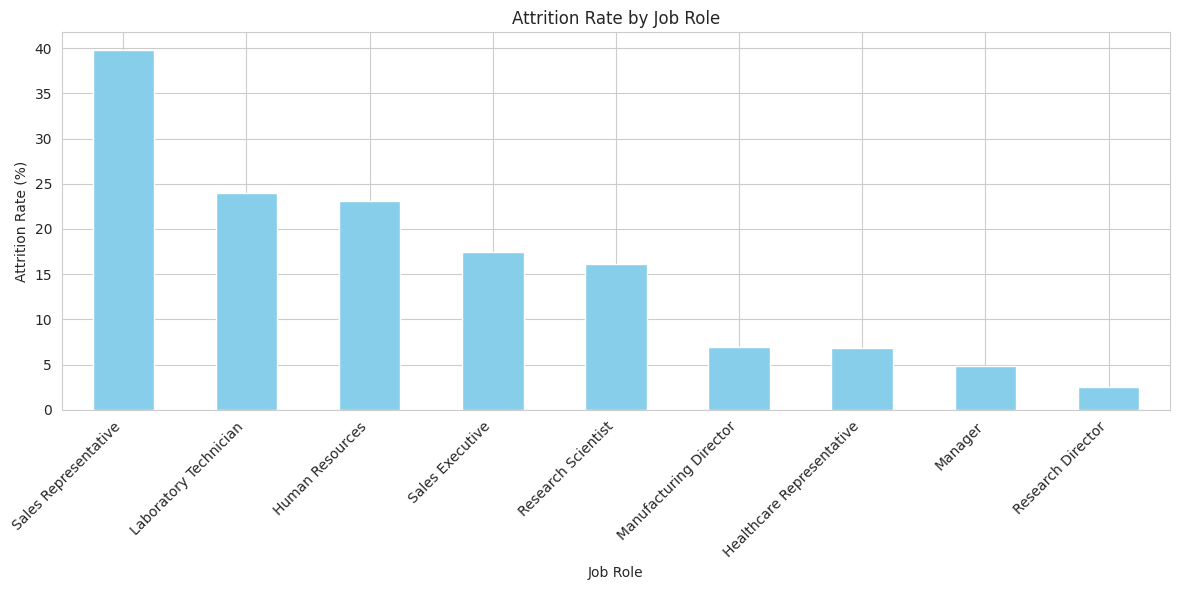

In [51]:
# Analyzing OverTime vs Attrition
plt.figure(figsize=(8, 5))
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='Set2')
plt.title('Impact of OverTime on Attrition')
plt.show()

# Analyzing JobRole vs Attrition
plt.figure(figsize=(12, 6))

# Calculate attrition rates by JobRole
attrition_by_job_role = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100

# Plotting the attrition rates
attrition_by_job_role['Yes'].sort_values(ascending=False).plot(kind='bar', color='skyblue')

plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Correlation Analysis**

The target variable is temporarily encoded numerically to compute correlations. A correlation heatmap is generated to examine relationships among numerical features, followed by a focused view of correlations with the attrition target.

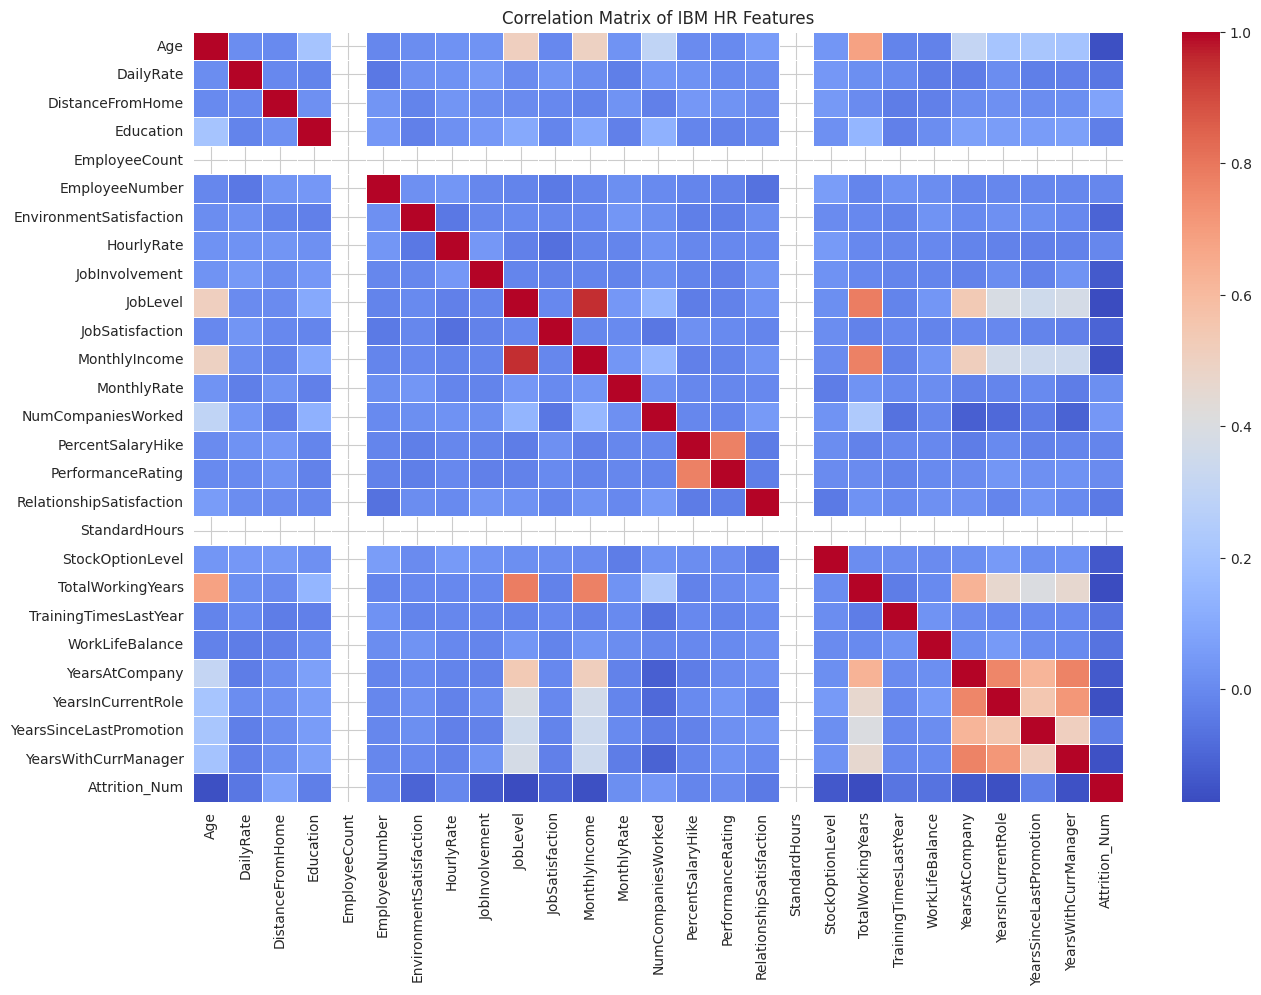

Correlation with Attrition:
Attrition_Num               1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHo

In [52]:
# 1. Converting Attrition to numerical (1 for Yes, 0 for No)
df['Attrition_Num'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Selecting only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()

# 3. Plotting the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of IBM HR Features')
plt.show()

# 4. Showing correlation specifically with the target
print("Correlation with Attrition:")
print(corr_matrix['Attrition_Num'].sort_values(ascending=False))

# **Data Reduction and Feature Selection**

Constant features, identifiers, and low-impact variables are removed to reduce dimensionality and prevent data leakage. The final column count is verified before modelling.

In [53]:
# 1. Defining redundant or non-predictive columns
cols_to_drop = [
    'EmployeeCount',
    'StandardHours',
    'Over18',
    'EmployeeNumber',
    'PerformanceRating',
    'HourlyRate',
    'PercentSalaryHike',
    'MonthlyRate'
]

# 2. Removing temporary encoded target if it exists (to prevent leakage)
if 'Attrition_Num' in df.columns:
    cols_to_drop.append('Attrition_Num')

# 3. Dropping columns safely
df_final = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 4. Verification summary
print("DATA REDUCTION SUMMARY")
print(f"Original number of columns: {df.shape[1]}")
print(f"Number of columns removed: {len(cols_to_drop)}")
print(f"Final number of columns: {df_final.shape[1]}")

DATA REDUCTION SUMMARY
Original number of columns: 36
Number of columns removed: 9
Final number of columns: 27


# **Feature Encoding and Target Separation**

The cleaned dataset is prepared for modelling by encoding categorical variables and converting the target variable to binary format. Predictor variables (X) and the target variable (y) are then separated.

In [54]:
# Create modelling copy
df_model = df_final.copy()

# Encode target only
df_model['Attrition'] = df_model['Attrition'].map({'No': 0, 'Yes': 1})

# One-hot encode categorical feature columns
df_model = pd.get_dummies(df_model, drop_first=True)

# Separate X and y
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

# **Train-Test Split and Feature Scaling**

The dataset is split into training (70%) and testing (30%) sets using stratified sampling to preserve class distribution. Feature scaling is applied for Logistic Regression, which is sensitive to feature magnitude.

In [55]:
# 70/30 split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Scaling (ONLY for Logistic Regression later)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Feature Importance Analysis (Random Forest)**

A Random Forest model is trained to identify the most influential predictors of employee attrition. Feature importance scores are extracted and the top contributing variables are visualised.

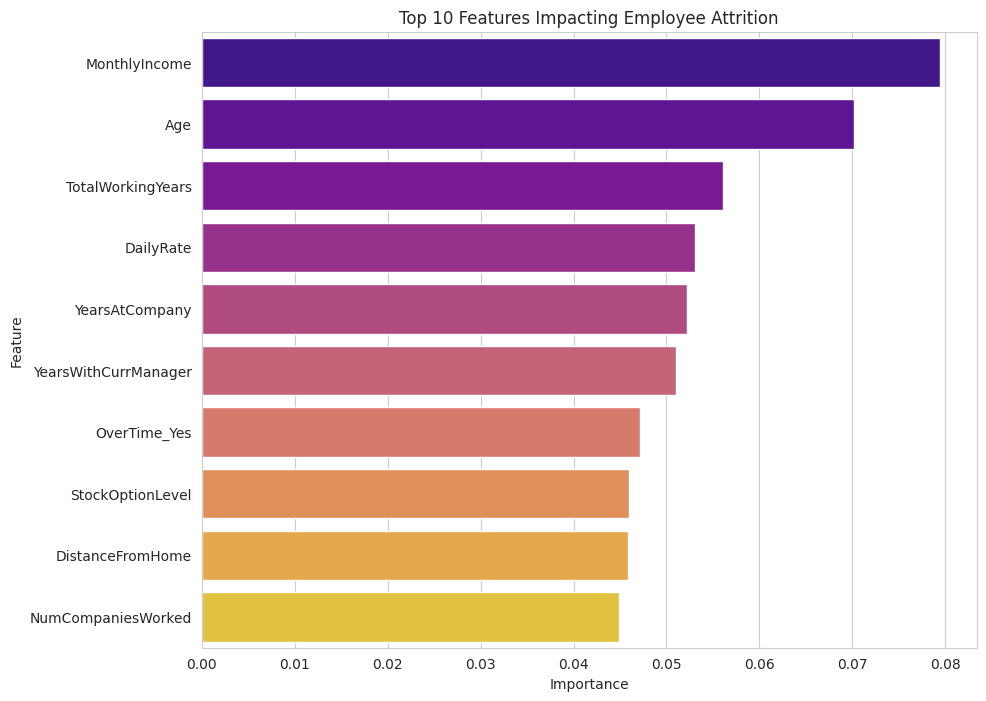

                 Feature  Importance
8          MonthlyIncome    0.079392
0                    Age    0.070190
12     TotalWorkingYears    0.056046
1              DailyRate    0.053025
15        YearsAtCompany    0.052167
18  YearsWithCurrManager    0.051018
39          OverTime_Yes    0.047187
11      StockOptionLevel    0.045937
2       DistanceFromHome    0.045863
9     NumCompaniesWorked    0.044851


In [56]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    hue='Feature',
    data=feature_importance_df.head(10),
    palette='plasma',
    legend=False
)
plt.title('Top 10 Features Impacting Employee Attrition')
plt.show()

print(feature_importance_df.head(10))

# **Model Preparation for Classification**

The cleaned dataset is one-hot encoded and split into predictor variables (X) and the binary target (Attrition_Yes). A 70/30 stratified train-test split is applied, and feature scaling is performed for Logistic Regression.

In [57]:
# One-hot encoding
df_ml = pd.get_dummies(df_final, drop_first=True)

# Define X and y
X = df_ml.drop('Attrition_Yes', axis=1)
y = df_ml['Attrition_Yes']

# 70% Train / 30% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Scaling (for Logistic Regression only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Model Training and Evaluation**

Logistic Regression, Decision Tree, and Random Forest classifiers are trained using class-weight balancing to address class imbalance. Models are evaluated on the test set using confusion matrices and classification metrics (precision, recall, and F1-score).

In [58]:
# Initialize models with imbalance handling
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
dec_tree = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
rand_forest = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dec_tree,
    "Random Forest": rand_forest
}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    print(f"\n--- {name} Performance ---")
    print(confusion_matrix(y_test, predictions))
    print(classification_report(y_test, predictions))


--- Logistic Regression Performance ---
[[288  82]
 [ 23  48]]
              precision    recall  f1-score   support

       False       0.93      0.78      0.85       370
        True       0.37      0.68      0.48        71

    accuracy                           0.76       441
   macro avg       0.65      0.73      0.66       441
weighted avg       0.84      0.76      0.79       441


--- Decision Tree Performance ---
[[281  89]
 [ 29  42]]
              precision    recall  f1-score   support

       False       0.91      0.76      0.83       370
        True       0.32      0.59      0.42        71

    accuracy                           0.73       441
   macro avg       0.61      0.68      0.62       441
weighted avg       0.81      0.73      0.76       441


--- Random Forest Performance ---
[[363   7]
 [ 63   8]]
              precision    recall  f1-score   support

       False       0.85      0.98      0.91       370
        True       0.53      0.11      0.19        71

  

# **Clustering Preparation and Model Training**

Selected numerical features are scaled and used for clustering. Silhouette scores are computed to select an appropriate k value, followed by fitting K-Means and Agglomerative Clustering to assign cluster labels.

In [59]:
# 1) Select numerical features for clustering
features_for_clustering = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome']
X_cluster = df_final[features_for_clustering].copy()

# 2) Scale features (required)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3) Evaluate k using silhouette
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k} silhouette={score:.3f}")

# 4) Fit final KMeans (example k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_final['KMeans_Labels'] = kmeans.fit_predict(X_scaled)

# 5) Fit Agglomerative clustering (k=2)
hierarchical = AgglomerativeClustering(n_clusters=2)
df_final['Hierarchical_Labels'] = hierarchical.fit_predict(X_scaled)

k=2 silhouette=0.438
k=3 silhouette=0.307
k=4 silhouette=0.257
k=5 silhouette=0.268
k=6 silhouette=0.274


# **Cluster Profiling**

Cluster means are calculated to interpret and compare employee characteristics across the identified K-Means segments.

In [60]:
df_final.groupby("KMeans_Labels")[features_for_clustering].mean()

,Age,MonthlyIncome,TotalWorkingYears,YearsAtCompany,DistanceFromHome
KMeans_Labels,,,,,
0,34.438345,4694.250845,8.270270,5.333615,9.217061
1,47.213287,13990.615385,23.737762,13.940559,9.090909


# **Cluster Comparison**

A cross-tabulation is generated to compare K-Means and Agglomerative cluster assignments and assess agreement between the two methods.

In [61]:
pd.crosstab(df_final['KMeans_Labels'], df_final['Hierarchical_Labels'])

Hierarchical_Labels,0,1
KMeans_Labels,,
0,1163,21
1,41,245


# **Elbow Method**

The Elbow Method is applied by plotting the Within-Cluster Sum of Squares (WCSS) for k values from 1 to 10 to identify an appropriate number of clusters.

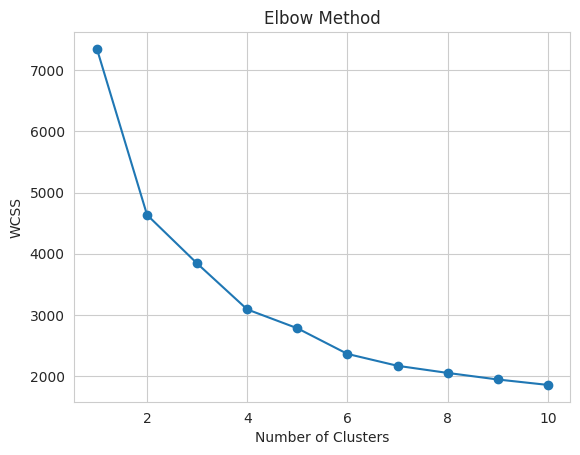

In [62]:
# Code to find the Elbow
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()